# Humanitarian Response Coverage Analysis (2024-2026)

This notebook analyzes humanitarian response coverage across 2024-2026 by combining two critical datasets:

* **FTS (Financial Tracking System)**: Tracks humanitarian funding requirements and actual funding received
* **HPC (Humanitarian Programme Cycle)**: Tracks population needs - people in need, targeted, and reached

## Combined Coverage Metric

We calculate a **combined coverage metric** that multiplies funding performance with targeting performance:

```
Combined Coverage = (% Funded) × (% Targeted)

Where:
- % Funded = (Funding / Requirements) × 100
- % Targeted = (Targeted / In Need) × 100
```

This metric identifies clusters and countries where **both** funding and targeting are strong (or weak), helping prioritize humanitarian interventions. A score of 100 would mean 100% funded AND 100% of people in need are targeted.

## Notebook Structure

* **Single-year analysis (2025)**: Detailed breakdown by country/cluster for the most recent complete year
* **Multi-year analysis (2024-2026)**: Historical comparison showing trends and year-over-year changes

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve data folder for local execution.
base_path = Path.cwd()
data_path = base_path / "data" if (base_path / "data").exists() else base_path

fts = pd.read_csv(data_path / "fts_requirements_funding_globalcluster_global.csv")
hpc_2024 = pd.read_csv(data_path / "hpc_hno_2024.csv")
hpc_2025 = pd.read_csv(data_path / "hpc_hno_2025.csv")
hpc_2026 = pd.read_csv(data_path / "hpc_hno_2026.csv")

cluster_mapping = {
    "CCM": "Camp Coordination / Management",
    "CSS": "Coordination and support services",
    "EDU": "Education",
    "ERY": "Early Recovery",
    "FSC": "Food Security",
    "HEA": "Health",
    "LOG": "Logistics",
    "MPC": "Multipurpose Cash",
    "MS": "Multi-sector",
    "NUT": "Nutrition",
    "PRO": "Protection",
    "PRO-CPN": "Protection - Child Protection",
    "PRO-GBV": "Protection - Gender-Based Violence",
    "PRO-HLP": "Protection - Housing, Land and Property",
    "PRO-MIN": "Protection - Mine Action",
    "SHL": "Emergency Shelter and NFI",
    "TEL": "Emergency Telecommunications",
    "WSH": "Water Sanitation Hygiene",
}


def prep_hpc_country_cluster(df: pd.DataFrame, year: int) -> pd.DataFrame:
    d = df.copy()
    d.columns = [c.strip() for c in d.columns]

    d["Cluster"] = d["Cluster"].astype(str).str.strip()
    d["cluster"] = d["Cluster"].map(cluster_mapping)
    d = d[d["cluster"].notna()].copy()

    for col in ["In Need", "Targeted", "Reached"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce")

    if year in (2024, 2025):
        d = d[d["Category"].astype(str).str.lower() == "total"]
        for admin_col in ["Admin 1 Name", "Admin 2 Name", "Admin 3 Name"]:
            if admin_col in d.columns:
                d = d[d[admin_col].isna()]
    else:
        d = d[d["Cluster"].str.upper() != "ALL"]

    out = (
        d.groupby(["Country ISO3", "cluster"], as_index=False)[["In Need", "Targeted", "Reached"]]
        .sum(min_count=1)
        .rename(
            columns={
                "Country ISO3": "country_code",
                "In Need": "in_need",
                "Targeted": "targeted",
                "Reached": "reached",
            }
        )
    )
    out["year"] = year
    return out


fts_2025 = (
    fts[fts["year"] == 2025]
    .groupby(["countryCode", "cluster"], as_index=False)[["requirements", "funding"]]
    .sum(min_count=1)
    .rename(columns={"countryCode": "country_code"})
)
fts_2025["percent_funded"] = np.where(
    fts_2025["requirements"] > 0,
    (fts_2025["funding"] / fts_2025["requirements"]) * 100,
    np.nan,
)

hpc_2025_agg = prep_hpc_country_cluster(hpc_2025, 2025)

result_country_cluster_2025 = fts_2025.merge(
    hpc_2025_agg,
    on=["country_code", "cluster"],
    how="outer",
)

result_country_cluster_2025["percent_targeted"] = np.where(
    result_country_cluster_2025["in_need"] > 0,
    (result_country_cluster_2025["targeted"] / result_country_cluster_2025["in_need"]) * 100,
    np.nan,
)
result_country_cluster_2025["combined_coverage_metric"] = np.where(
    (result_country_cluster_2025["requirements"] > 0) & (result_country_cluster_2025["in_need"] > 0),
    (result_country_cluster_2025["funding"] / result_country_cluster_2025["requirements"])
    * (result_country_cluster_2025["targeted"] / result_country_cluster_2025["in_need"])
    * 100,
    np.nan,
)

result_country_cluster_2025 = result_country_cluster_2025[
    result_country_cluster_2025["country_code"].notna()
].sort_values("combined_coverage_metric", ascending=False, na_position="last")

result_country_cluster_2025.head(20)

/var/folders/n7/pscbskrs56g3vq7h0mq8nh8m0000gn/T/ipykernel_20240/1036155097.py:11: DtypeWarning: Columns (1,2,3,4,5,6,10,11,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  hpc_2024 = pd.read_csv(data_path / "hpc_hno_2024.csv")
/var/folders/n7/pscbskrs56g3vq7h0mq8nh8m0000gn/T/ipykernel_20240/1036155097.py:12: DtypeWarning: Columns (1,2,5,6,10,11,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  hpc_2025 = pd.read_csv(data_path / "hpc_hno_2025.csv")


,country_code,cluster,requirements,funding,percent_funded,in_need,targeted,reached,year,percent_targeted,combined_coverage_metric
474,TCD,Protection,6141970.0,17505756.0,285.018585,727581.0,562907.0,NaN,2025.0,77.366919,220.510097
72,CAF,Protection - Gender-Based Violence,9855993.0,10103158.0,102.507764,910131.0,622460.0,NaN,2025.0,68.392352,70.107471
533,YEM,Multi-sector,48255505.0,32794973.0,67.961102,192522.0,192522.0,NaN,2025.0,100.000000,67.961102
412,SOM,Protection,21794210.0,19985339.0,91.700222,4153704.0,3041134.0,NaN,2025.0,73.214991,67.138309
383,SLV,Camp Coordination / Management,1130000.0,1468699.0,129.973363,29081.0,14982.0,NaN,2025.0,51.518173,66.959902
304,NGA,Protection,11164685.0,14590671.0,130.685917,3961393.0,1912669.0,NaN,2025.0,48.282738,63.098739
525,YEM,Coordination and support services,31631755.0,18606497.0,58.822209,520000.0,520000.0,NaN,2025.0,100.000000,58.822209
479,UKR,Camp Coordination / Management,20366691.0,21897590.0,107.516680,148900.0,78913.0,NaN,2025.0,52.997314,56.980952
14,AFG,Protection,37833707.0,79855072.0,211.068590,36472072.0,8746546.0,NaN,2025.0,23.981489,50.617391
429,SSD,Multipurpose Cash,25000010.0,18444089.0,73.776326,3272315.0,2239146.0,NaN,2025.0,68.426970,50.482905


## Why Combine Funding and Targeting?

The combined coverage metric helps identify:

* **High performers**: Well-funded responses that also reach a large proportion of people in need
* **Hidden gaps**: Responses that may be well-funded but only target a small fraction of those in need (or vice versa)
* **Critical shortfalls**: Clusters/countries with both low funding AND low targeting rates

**Example interpretations:**
* Score of **50**: Could be 100% funded but only 50% targeted, OR 50% funded and 100% targeted, OR 70% funded and 71% targeted
* Score of **20**: Indicates serious gaps - likely both underfunded AND under-targeted
* Score of **0**: No funding received, or no population targeted

This metric is particularly useful for resource allocation decisions and advocacy priorities.

In [18]:
hpc_cluster_2025 = (
    hpc_2025_agg.groupby("cluster", as_index=False)[["in_need", "targeted", "reached"]]
    .sum(min_count=1)
)

fts_cluster_2025 = (
    fts[fts["year"] == 2025]
    .groupby("cluster", as_index=False)[["requirements", "funding"]]
    .sum(min_count=1)
)

result_cluster_2025 = fts_cluster_2025.merge(hpc_cluster_2025, on="cluster", how="outer")

result_cluster_2025["percent_funded"] = np.where(
    result_cluster_2025["requirements"] > 0,
    (result_cluster_2025["funding"] / result_cluster_2025["requirements"]) * 100,
    np.nan,
)
result_cluster_2025["percent_targeted"] = np.where(
    result_cluster_2025["in_need"] > 0,
    (result_cluster_2025["targeted"] / result_cluster_2025["in_need"]) * 100,
    np.nan,
)
result_cluster_2025["combined_coverage_metric"] = np.where(
    (result_cluster_2025["requirements"] > 0) & (result_cluster_2025["in_need"] > 0),
    (result_cluster_2025["funding"] / result_cluster_2025["requirements"])
    * (result_cluster_2025["targeted"] / result_cluster_2025["in_need"])
    * 100,
    np.nan,
)

result_cluster_2025 = result_cluster_2025[
    result_cluster_2025["cluster"].notna()
].sort_values("combined_coverage_metric", ascending=False, na_position="last")

result_cluster_2025.head(20)

,cluster,requirements,funding,in_need,targeted,reached,percent_funded,percent_targeted,combined_coverage_metric
12,Multipurpose Cash,1.634808e+09,7.766760e+08,3272315.0,1.118308e+07,NaN,47.508692,341.748365,162.360178
9,Logistics,5.454698e+08,2.111526e+08,12650.0,1.265000e+04,NaN,38.710232,100.000000,38.710232
2,Coordination and support services,7.257198e+08,2.717659e+08,520000.0,5.200000e+05,NaN,37.447772,100.000000,37.447772
16,Protection,9.995777e+08,7.543592e+08,176622273.0,5.497744e+07,NaN,75.467790,31.127125,23.490953
10,Multi-sector,2.607254e+09,6.424015e+08,4227050.0,3.953670e+06,NaN,24.639006,93.532605,23.045505
8,Health,3.404454e+09,1.574262e+09,136285868.0,6.509242e+07,NaN,46.241246,47.761683,22.085598
14,Nutrition,2.740528e+09,7.282448e+08,52660241.0,3.597356e+07,NaN,26.573159,68.312561,18.152806
7,Food Security,1.219259e+10,4.036561e+09,150033706.0,8.126366e+07,NaN,33.106681,54.163602,17.931771
21,Protection - Mine Action,3.432490e+08,1.862310e+08,48387463.0,1.397123e+07,NaN,54.255360,28.873665,15.665511
3,Early Recovery,3.014282e+08,4.537021e+08,6044222.0,6.149060e+05,NaN,150.517455,10.173452,15.312820


## Best Performing Clusters (Globally)

1. **Multipurpose Cash** (162.4): Over-targeted (342% of in-need population) with moderate funding (47.5%)
2. **Logistics** (38.7): Fully targeted (100%) with moderate funding (38.7%)
3. **Coordination and Support Services** (37.4): Fully targeted (100%) with moderate funding (37.4%)
4. **Protection** (23.5): Well-funded (75.5%) but only 31% of in-need population targeted
5. **Multi-sector** (23.0): Low funding (24.6%) but high targeting (93.5%)

## Worst Performing Clusters (Globally)

1. **Protection - Housing, Land and Property** (3.3): Only 11.4% funded, 29% targeted - affecting 13.9M people
2. **Protection - Gender-Based Violence** (7.7): 29.2% funded, 26.3% targeted - affecting 71.1M people
3. **Emergency Shelter and NFI** (8.1): 26.9% funded, 30.2% targeted - affecting 72.1M people
4. **Protection - Child Protection** (8.9): 26.7% funded, 33.2% targeted - affecting 64.4M people
5. **Water Sanitation Hygiene** (10.8): 22.8% funded, 47.5% targeted - affecting 127.0M people

## Largest Absolute Gaps

* **Food Security**: $12.2B requirements, $4.0B funded (33.1%), 150M people in need, 81M targeted (54.2%) - Combined metric: 17.9
* **Health**: $3.4B requirements, $1.6B funded (46.2%), 136M people in need, 65M targeted (47.8%) - Combined metric: 22.1
* **Water/Sanitation**: $3.3B requirements, $752M funded (22.8%), 127M people in need, 60M targeted (47.5%) - Combined metric: 10.8

Protection sub-sectors consistently underperform despite affecting 149M people combined.

In [19]:
hpc_country_2025 = (
    hpc_2025_agg.groupby("country_code", as_index=False)[["in_need", "targeted", "reached"]]
    .sum(min_count=1)
)

fts_country_2025 = (
    fts[fts["year"] == 2025]
    .groupby("countryCode", as_index=False)[["requirements", "funding"]]
    .sum(min_count=1)
    .rename(columns={"countryCode": "country_code"})
)

result_country_2025 = fts_country_2025.merge(hpc_country_2025, on="country_code", how="outer")

result_country_2025["percent_funded"] = np.where(
    result_country_2025["requirements"] > 0,
    (result_country_2025["funding"] / result_country_2025["requirements"]) * 100,
    np.nan,
)
result_country_2025["percent_targeted"] = np.where(
    result_country_2025["in_need"] > 0,
    (result_country_2025["targeted"] / result_country_2025["in_need"]) * 100,
    np.nan,
)
result_country_2025["combined_coverage_metric"] = np.where(
    (result_country_2025["requirements"] > 0) & (result_country_2025["in_need"] > 0),
    (result_country_2025["funding"] / result_country_2025["requirements"])
    * (result_country_2025["targeted"] / result_country_2025["in_need"])
    * 100,
    np.nan,
)

result_country_2025 = result_country_2025[
    result_country_2025["country_code"].notna()
].sort_values("combined_coverage_metric", ascending=False, na_position="last")

result_country_2025.head(20)

,country_code,requirements,funding,in_need,targeted,reached,percent_funded,percent_targeted,combined_coverage_metric
27,UKR,2.633534e+09,1.699331e+09,62093824.0,2.542852e+07,NaN,64.526627,40.951762,26.424791
3,CAF,3.260566e+08,1.355570e+08,11057438.0,6.182181e+06,NaN,41.574688,55.909705,23.244286
26,TCD,1.454258e+09,4.563276e+08,20627283.0,1.299116e+07,NaN,31.378720,62.980486,19.762470
16,NER,6.030276e+08,1.578801e+08,9942797.0,7.308348e+06,NaN,26.181235,73.503945,19.244241
24,SSD,1.694779e+09,7.801153e+08,49035310.0,1.995443e+07,NaN,46.030510,40.694006,18.731658
23,SOM,1.421989e+09,4.093496e+08,41221007.0,2.515325e+07,NaN,28.787118,61.020462,17.566032
14,MOZ,6.827230e+08,1.604566e+08,7110160.0,5.108380e+06,NaN,23.502441,71.846203,16.885611
12,MLI,7.713143e+08,1.986761e+08,28302641.0,1.852535e+07,NaN,25.758123,65.454496,16.859850
21,SDN,4.162519e+09,1.645601e+09,148160173.0,6.306910e+07,NaN,39.533778,42.568189,16.828813
17,NGA,9.102465e+08,2.871878e+08,38735620.0,2.016853e+07,NaN,31.550556,52.067149,16.427475


## Best Performing Countries

1. **Ukraine (UKR)** - 26.4: $2.6B requirements, 64.5% funded | 62.1M in need, 41.0% targeted
2. **Central African Republic (CAF)** - 23.2: $326M requirements, 41.6% funded | 11.1M in need, 55.9% targeted
3. **Chad (TCD)** - 19.8: $1.5B requirements, 31.4% funded | 20.6M in need, 63.0% targeted
4. **Niger (NER)** - 19.2: $603M requirements, 26.2% funded | 9.9M in need, 73.5% targeted
5. **South Sudan (SSD)** - 18.7: $1.7B requirements, 46.0% funded | 49.0M in need, 40.7% targeted

## Worst Performing Countries

1. **Colombia (COL)** - 3.0: $342M requirements, 27.8% funded | **41.3M in need, only 10.9% targeted**
2. **Guatemala (GTM)** - 4.8: $101M requirements, 24.9% funded | 5.9M in need, 19.3% targeted
3. **Honduras (HND)** - 4.8: $138M requirements, 10.6% funded | 396K in need, 45.3% targeted
4. **El Salvador (SLV)** - 6.3: $67M requirements, 28.4% funded | 3.9M in need, 22.3% targeted
5. **Myanmar (MMR)** - 7.0: $1.4B requirements, 28.5% funded | 88.7M in need, 24.4% targeted

## Largest Crises (Moderate Coverage, Massive Scale)

* **Sudan (SDN)** - 16.8: $4.2B requirements, 39.5% funded | **148.2M in need**, 42.6% targeted
* **Afghanistan (AFG)** - 16.1: $2.4B requirements, 41.7% funded | **140.2M in need**, 38.6% targeted
* **Yemen (YEM)** - 12.5: $2.5B requirements, 29.0% funded | **130.1M in need**, 43.0% targeted
* **DRC (COD)** - 12.7: $2.5B requirements, 27.2% funded | **79.2M in need**, 46.9% targeted

## Key Insights

* **Central America** (COL, GTM, HND, SLV) consistently underperforms - low targeting rates are the primary driver
* **Colombia's crisis**: Despite 41.3M people in need, only 4.5M (10.9%) are targeted - the lowest targeting rate globally
* **Scale matters**: Afghanistan, Sudan, and Yemen represent over 400M people in need with moderate coverage (12-16), creating massive absolute gaps
* **Ukraine** leads in both absolute funding ($1.7B received) and combined metric (26.4), showing strong donor commitment

# Multi-Year Analysis (2024-2026)

This section adds historical comparison to track year-over-year trends in humanitarian funding and coverage. By comparing 2024, 2025, and 2026 data, we can identify:

* **Improving situations**: Countries/clusters where combined coverage increased
* **Deteriorating crises**: Where coverage decreased despite ongoing or worsening needs
* **Funding trends**: Whether donor commitment is increasing or declining
* **Scale changes**: How populations in need are growing or shrinking

The analysis combines data from all three years using the same methodology and metrics for consistency.

**Note**: The 2026 HPC dataset has a simplified structure (no administrative subdivisions, no category breakdowns) compared to 2024/2025, but uses the same cluster codes and metrics.

In [20]:
hpc_multi = pd.concat(
    [
        prep_hpc_country_cluster(hpc_2024, 2024),
        prep_hpc_country_cluster(hpc_2025, 2025),
        prep_hpc_country_cluster(hpc_2026, 2026),
    ],
    ignore_index=True,
)

fts_multi = (
    fts[fts["year"].isin([2024, 2025, 2026])]
    .groupby(["year", "countryCode", "cluster"], as_index=False)[["requirements", "funding"]]
    .sum(min_count=1)
    .rename(columns={"countryCode": "country_code"})
)

result_country_cluster_multi = fts_multi.merge(
    hpc_multi,
    on=["year", "country_code", "cluster"],
    how="outer",
)

result_country_cluster_multi["percent_funded"] = np.where(
    result_country_cluster_multi["requirements"] > 0,
    (result_country_cluster_multi["funding"] / result_country_cluster_multi["requirements"]) * 100,
    np.nan,
)
result_country_cluster_multi["percent_targeted"] = np.where(
    result_country_cluster_multi["in_need"] > 0,
    (result_country_cluster_multi["targeted"] / result_country_cluster_multi["in_need"]) * 100,
    np.nan,
)
result_country_cluster_multi["combined_coverage_metric"] = np.where(
    (result_country_cluster_multi["requirements"] > 0) & (result_country_cluster_multi["in_need"] > 0),
    (result_country_cluster_multi["funding"] / result_country_cluster_multi["requirements"])
    * (result_country_cluster_multi["targeted"] / result_country_cluster_multi["in_need"])
    * 100,
    np.nan,
)

result_country_cluster_multi = result_country_cluster_multi[
    result_country_cluster_multi["country_code"].notna()
].sort_values(["year", "combined_coverage_metric"], ascending=[False, False], na_position="last")

result_country_cluster_multi.head(30)

,year,country_code,cluster,requirements,funding,in_need,targeted,reached,percent_funded,percent_targeted,combined_coverage_metric
1630,2026,TCD,Protection,6681127.0,7956925.0,924494.0,890816.0,NaN,119.095551,96.357142,114.757069
1595,2026,SSD,Protection,16246140.0,22408194.0,4867750.0,1548355.0,NaN,137.929342,31.808433,43.873162
1470,2026,MOZ,Protection,23884941.0,14988575.0,2988825.0,1763845.0,NaN,62.753243,59.014663,37.033615
1285,2026,CAF,Protection,9309240.0,5334261.0,2086488.0,1066547.0,NaN,57.300714,51.116853,29.290322
1622,2026,TCD,Emergency Shelter and NFI,29760867.0,8078489.0,504194.0,482348.0,NaN,27.144670,95.667144,25.968530
1313,2026,COD,Multi-sector,102604294.0,24407448.0,512680.0,458749.0,NaN,23.787940,89.480573,21.285585
1624,2026,TCD,Health,45505747.0,11924971.0,1706766.0,1203856.0,NaN,26.205418,70.534332,18.483816
1318,2026,COD,Protection,22052792.0,16562280.0,10845464.0,2464366.0,NaN,75.102871,22.722550,17.065288
1471,2026,MOZ,Protection - Child Protection,18877928.0,3995074.0,894050.0,649530.0,NaN,21.162672,72.650299,15.374745
1645,2026,UKR,Education,58763796.0,15546984.0,846540.0,487663.0,NaN,26.456739,57.606610,15.240830


In [21]:
hpc_cluster_multi = (
    hpc_multi.groupby(["year", "cluster"], as_index=False)[["in_need", "targeted", "reached"]]
    .sum(min_count=1)
)

fts_cluster_multi = (
    fts[fts["year"].isin([2024, 2025, 2026])]
    .groupby(["year", "cluster"], as_index=False)[["requirements", "funding"]]
    .sum(min_count=1)
)

cluster_multi = fts_cluster_multi.merge(hpc_cluster_multi, on=["year", "cluster"], how="outer")

cluster_multi["percent_funded"] = np.where(
    cluster_multi["requirements"] > 0,
    (cluster_multi["funding"] / cluster_multi["requirements"]) * 100,
    np.nan,
)
cluster_multi["percent_targeted"] = np.where(
    cluster_multi["in_need"] > 0,
    (cluster_multi["targeted"] / cluster_multi["in_need"]) * 100,
    np.nan,
)
cluster_multi["combined_coverage_metric"] = np.where(
    (cluster_multi["requirements"] > 0) & (cluster_multi["in_need"] > 0),
    (cluster_multi["funding"] / cluster_multi["requirements"])
    * (cluster_multi["targeted"] / cluster_multi["in_need"])
    * 100,
    np.nan,
)

cluster_wide = cluster_multi.pivot_table(index="cluster", columns="year", values=[
    "in_need",
    "requirements",
    "funding",
    "percent_funded",
    "combined_coverage_metric",
], aggfunc="first")

cluster_wide.columns = [f"{metric}_{year}" for metric, year in cluster_wide.columns]
cluster_wide = cluster_wide.reset_index()
cluster_wide["change_2024_to_2026"] = (
    cluster_wide["combined_coverage_metric_2026"] - cluster_wide["combined_coverage_metric_2024"]
).round(1)

cluster_wide.sort_values("change_2024_to_2026", ascending=False, na_position="last").head(30)

,cluster,combined_coverage_metric_2024,combined_coverage_metric_2025,combined_coverage_metric_2026,funding_2024,funding_2025,funding_2026,in_need_2024,in_need_2025,in_need_2026,percent_funded_2024,percent_funded_2025,percent_funded_2026,requirements_2024,requirements_2025,requirements_2026,change_2024_to_2026
21,Protection - Mine Action,15.946366,15.665511,19.409544,1.849082e+08,1.862310e+08,8.344972e+07,4.756072e+07,48387463.0,2929499.0,56.204593,54.255360,56.381224,3.289913e+08,3.432490e+08,1.480098e+08,3.5
19,"Protection - Housing, Land and Property",6.339648,3.322125,3.617607,2.308896e+07,6.743126e+06,5.064921e+06,2.097311e+07,13868314.0,2988903.0,28.205583,11.437169,17.069314,8.185953e+07,5.895800e+07,2.967267e+07,-2.7
18,Protection - Gender-Based Violence,8.122497,7.673694,2.775934,3.038945e+08,2.587025e+08,3.738173e+07,7.752139e+07,71101254.0,10294552.0,31.183649,29.176235,9.665082,9.745315e+08,8.866893e+08,3.867709e+08,-5.3
5,Emergency Shelter and NFI,11.327361,8.121693,3.105946,1.144395e+09,7.817267e+08,2.492895e+08,8.434114e+07,72057833.0,40950569.0,32.754056,26.928049,10.672299,3.493904e+09,2.903020e+09,2.335855e+09,-8.2
17,Protection - Child Protection,15.116546,8.884448,3.566909,4.203355e+08,2.739319e+08,4.308411e+07,6.209495e+07,64358933.0,8197641.0,38.137992,26.722653,9.041023,1.102144e+09,1.025092e+09,4.765402e+08,-11.5
4,Education,14.685042,13.041517,3.134340,7.029076e+08,6.359855e+08,1.602764e+08,7.193806e+07,55704639.0,25397687.0,36.121985,37.254127,11.092658,1.945927e+09,1.707154e+09,1.444887e+09,-11.6
22,Water Sanitation Hygiene,19.611189,10.835407,4.040495,1.284375e+09,7.518042e+08,2.569640e+08,1.567829e+08,127004965.0,61559042.0,37.814566,22.823977,9.055618,3.396508e+09,3.293923e+09,2.837620e+09,-15.6
1,Camp Coordination / Management,22.030323,11.584150,4.436106,1.207012e+08,8.728292e+07,2.475216e+07,1.890467e+07,18712266.0,9926702.0,30.280684,21.007148,9.828599,3.986079e+08,4.154915e+08,2.518381e+08,-17.6
8,Health,25.010091,22.085598,6.579778,1.817379e+09,1.574262e+09,4.179318e+08,1.736945e+08,136285868.0,59648869.0,50.103807,46.241246,15.463900,3.627227e+09,3.404454e+09,2.702628e+09,-18.4
7,Food Security,28.613195,17.931771,5.785613,7.527494e+09,4.036561e+09,1.007863e+09,1.852977e+08,150033706.0,70597500.0,53.947408,33.106681,11.961808,1.395339e+10,1.219259e+10,8.425670e+09,-22.8


In [22]:
hpc_country_multi = (
    hpc_multi.groupby(["year", "country_code"], as_index=False)[["in_need", "targeted", "reached"]]
    .sum(min_count=1)
)

fts_country_multi = (
    fts[fts["year"].isin([2024, 2025, 2026])]
    .groupby(["year", "countryCode"], as_index=False)[["requirements", "funding"]]
    .sum(min_count=1)
    .rename(columns={"countryCode": "country_code"})
)

country_multi = fts_country_multi.merge(hpc_country_multi, on=["year", "country_code"], how="outer")

country_multi["percent_funded"] = np.where(
    country_multi["requirements"] > 0,
    (country_multi["funding"] / country_multi["requirements"]) * 100,
    np.nan,
)
country_multi["percent_targeted"] = np.where(
    country_multi["in_need"] > 0,
    (country_multi["targeted"] / country_multi["in_need"]) * 100,
    np.nan,
)
country_multi["combined_coverage_metric"] = np.where(
    (country_multi["requirements"] > 0) & (country_multi["in_need"] > 0),
    (country_multi["funding"] / country_multi["requirements"])
    * (country_multi["targeted"] / country_multi["in_need"])
    * 100,
    np.nan,
)

country_wide = country_multi.pivot_table(index="country_code", columns="year", values=[
    "in_need",
    "requirements",
    "funding",
    "percent_funded",
    "combined_coverage_metric",
], aggfunc="first")

country_wide.columns = [f"{metric}_{year}" for metric, year in country_wide.columns]
country_wide = country_wide.reset_index()
country_wide["change_2024_to_2026"] = (
    country_wide["combined_coverage_metric_2026"] - country_wide["combined_coverage_metric_2024"]
).round(1)

country_wide.sort_values("change_2024_to_2026", ascending=False, na_position="last").head(40)

,country_code,combined_coverage_metric_2024,combined_coverage_metric_2025,combined_coverage_metric_2026,funding_2024,funding_2025,funding_2026,in_need_2024,in_need_2025,in_need_2026,percent_funded_2024,percent_funded_2025,percent_funded_2026,requirements_2024,requirements_2025,requirements_2026,change_2024_to_2026
20,MMR,9.828601,6.968834,7.644365,3.955307e+08,4.028676e+08,245472134.0,8.650024e+07,88678655.0,52194280.0,39.809923,28.512285,27.593516,9.935481e+08,1.412962e+09,8.896008e+08,-2.2
22,MOZ,24.063648,16.885611,16.922161,1.957583e+08,1.604566e+08,131275217.0,8.792216e+06,7110160.0,13363353.0,38.961127,23.502441,24.567613,5.024452e+08,6.827230e+08,5.343426e+08,-7.1
6,COD,19.152029,12.738020,11.196408,1.322460e+09,6.893627e+08,430024823.0,1.030086e+08,79210438.0,64096801.0,51.245681,27.161477,30.634621,2.580628e+09,2.538016e+09,1.403722e+09,-8.0
13,HTI,20.262907,12.983509,9.147103,2.979224e+08,2.463134e+08,172057079.0,2.287916e+07,21412623.0,25575548.0,44.217393,27.122244,19.544669,6.737674e+08,9.081600e+08,8.803274e+08,-11.1
0,AFG,23.092888,16.098020,6.157495,1.583614e+09,1.008672e+09,214214587.0,1.454687e+08,140226170.0,81547687.0,51.759071,41.735637,12.496611,3.059588e+09,2.416812e+09,1.714181e+09,-16.9
35,TCD,32.517658,19.762470,14.541743,6.354197e+08,4.563276e+08,215913333.0,1.500203e+07,20627283.0,14723320.0,56.503208,31.378720,21.896358,1.124573e+09,1.454258e+09,9.860696e+08,-18.0
32,SOM,30.801097,17.566032,5.890731,9.035468e+08,4.093496e+08,111250193.0,4.721505e+07,41221007.0,30555192.0,59.715725,28.787118,13.057534,1.513080e+09,1.421989e+09,8.520000e+08,-24.9
37,UKR,36.619035,26.424791,11.534261,2.351068e+09,1.699331e+09,640227370.0,6.898652e+07,62093824.0,37814927.0,75.652918,64.526627,27.788105,3.107703e+09,2.633534e+09,2.303962e+09,-25.1
4,CAF,39.199958,23.244286,9.404270,2.570632e+08,1.355570e+08,47355888.0,1.451178e+07,11057438.0,9368756.0,77.505482,41.574688,17.931222,3.316710e+08,3.260566e+08,2.640974e+08,-29.8
25,NGA,42.209222,16.427475,11.920878,5.558041e+08,2.871878e+08,188766423.0,3.999608e+07,38735620.0,28776092.0,59.986887,31.550556,36.554344,9.265427e+08,9.102465e+08,5.163994e+08,-30.3


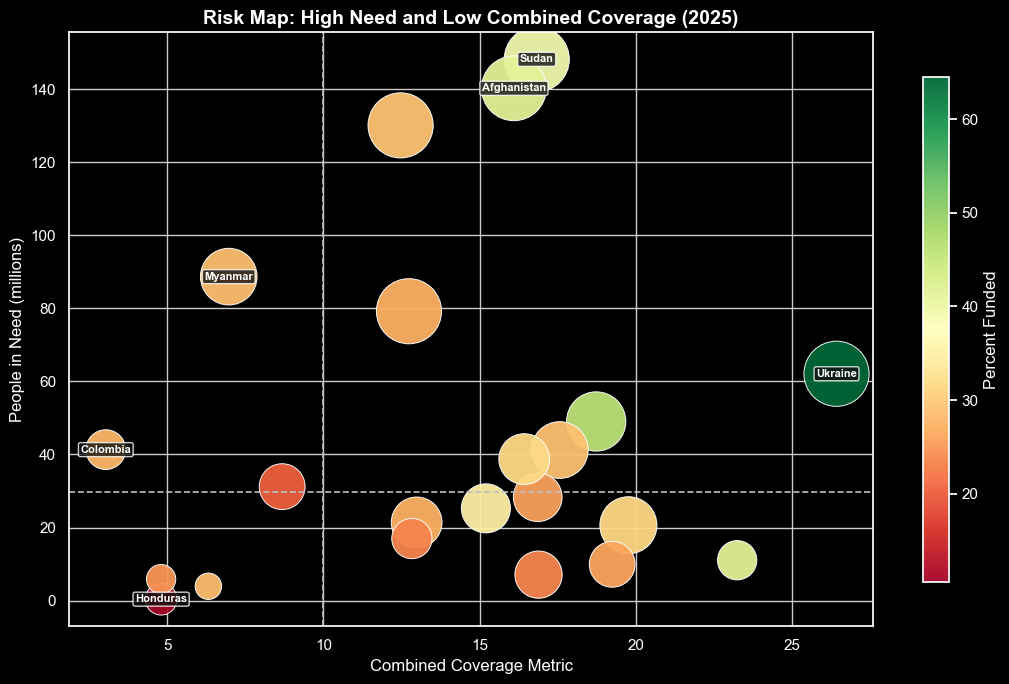

,country_name,country_code,percent_funded,in_need,funding_gap_usd,combined_coverage_metric
0,Afghanistan,AFG,41.735637,140226170.0,1.408140e+09,16.098020
6,Colombia,COL,27.774359,41329566.0,2.472344e+08,3.032857
9,Honduras,HND,10.609233,396425.0,1.237985e+08,4.804604
13,Myanmar,MMR,28.512285,88678655.0,1.010094e+09,6.968834
21,Sudan,SDN,39.533778,148160173.0,2.516918e+09,16.828813
27,Ukraine,UKR,64.526627,62093824.0,9.342034e+08,26.424791


In [36]:
# 2) High-need / low-funding risk map in 2025
import ast

risk_df = result_country_2025.copy()
risk_df["funding_gap_usd"] = risk_df["requirements"] - risk_df["funding"]
risk_df["in_need_m"] = risk_df["in_need"] / 1e6
risk_df = risk_df[(risk_df["in_need_m"] > 0) & (risk_df["percent_funded"].notna())].copy()

# Build a robust ISO3 -> country name map from local INFORM data first.
iso3_name_map = {}
try:
    inform_path = data_path / "inform-severity-index-sig.csv"
    inform_names = pd.read_csv(inform_path, usecols=["iso3", "country"])
    for _, r in inform_names.dropna().iterrows():
        try:
            iso_list = ast.literal_eval(r["iso3"]) if isinstance(r["iso3"], str) else []
            country_list = ast.literal_eval(r["country"]) if isinstance(r["country"], str) else []
            if isinstance(iso_list, list) and isinstance(country_list, list):
                for code, cname in zip(iso_list, country_list):
                    code = str(code).upper().strip()
                    cname = str(cname).strip()
                    if code and cname and code not in iso3_name_map:
                        iso3_name_map[code] = cname
        except Exception:
            continue
except Exception:
    pass

# Secondary fallback to pycountry (if available), then code.
try:
    import pycountry

    def iso3_to_country(code):
        code = str(code).upper().strip()
        if code in iso3_name_map:
            return iso3_name_map[code]
        match = pycountry.countries.get(alpha_3=code)
        return match.name if match else code
except Exception:
    def iso3_to_country(code):
        code = str(code).upper().strip()
        return iso3_name_map.get(code, code)

risk_df["country_name"] = risk_df["country_code"].astype(str).str.upper().apply(iso3_to_country)

x_threshold = 10  # low combined coverage line
y_threshold = risk_df["in_need_m"].median()

# Make bubble size reflect required funding with stronger visual separation.
req_billion = (risk_df["requirements"].fillna(0) / 1e9).clip(lower=0)
bubble_size = (np.sqrt(req_billion) * 1400).clip(80, 2200)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

sc = ax.scatter(
    risk_df["combined_coverage_metric"],
    risk_df["in_need_m"],
    s=bubble_size,
    c=risk_df["percent_funded"],
    cmap="RdYlGn",
    alpha=0.95,
    edgecolors="white",
    linewidth=0.7,
)

ax.axvline(x_threshold, color="#BFBFBF", linestyle="--", linewidth=1.2)
ax.axhline(y_threshold, color="#BFBFBF", linestyle="--", linewidth=1.2)

ax.set_title("Risk Map: High Need and Low Combined Coverage (2025)", fontsize=14, weight="bold", color="white")
ax.set_xlabel("Combined Coverage Metric", color="white")
ax.set_ylabel("People in Need (millions)", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("white")

# Label exactly these countries:
# 1) highest percent funded
# 2) lowest percent funded
# 3) two highest in need
# 4) worst combined coverage metric (minimum)
label_indices = set()
label_indices.add(risk_df["percent_funded"].idxmax())
label_indices.add(risk_df["percent_funded"].idxmin())
label_indices.update(risk_df.nlargest(2, "in_need").index.tolist())
label_indices.add(risk_df["combined_coverage_metric"].idxmin())

# Also label all countries above 80M people in need and below 10 combined coverage.
extra_labels = risk_df[(risk_df["in_need"] > 80_000_000) & (risk_df["combined_coverage_metric"] < 10)]
label_indices.update(extra_labels.index.tolist())

label_df = risk_df.loc[sorted(label_indices)].copy()

for _, row in label_df.iterrows():
    ax.text(
        row["combined_coverage_metric"],
        row["in_need_m"],
        row["country_name"],
        fontsize=8,
        weight="bold",
        ha="center",
        va="center",
        color="white",
        bbox=dict(boxstyle="round,pad=0.18", facecolor="#101010", alpha=0.8, edgecolor="white"),
    )

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Percent Funded", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")
cbar.outline.set_edgecolor("white")

plt.tight_layout()
plt.show()

label_df[["country_name", "country_code", "percent_funded", "in_need", "funding_gap_usd", "combined_coverage_metric"]]